# County-Level Cardiovascular Mortality Prediction with XGBoost

This notebook provides reproducibility analyses for a county-level cardiovascular disease (CVD) mortality prediction study in the contiguous United States. It trains a county-grouped XGBoost regression model, evaluates predictive performance on held-out counties, and quantifies predictor contributions using permutation importance and SHAP interpretability.

## Generated Artifacts

The notebook writes model outputs, diagnostic tables, figures, SHAP arrays, and the trained XGBoost model to the configured output directory. The generated files include model split metadata, performance metrics, prediction tables, feature-importance summaries, SHAP dependence data, residual diagnostics, and publication-quality figures.

Expected CSV outputs:
- `canonical_split_metadata.csv`
- `canonical_model_metrics.csv`
- `canonical_train_predictions.csv`
- `canonical_test_predictions.csv`
- `canonical_shap_ranking.csv`
- `canonical_permutation_importance.csv`
- `canonical_shap_dependence_top3_features.csv`
- `canonical_residual_diagnostics_summary.csv`

Expected figure outputs:
- `canonical_scatter_performance.png`
- `canonical_shap_summary.png`
- `canonical_permutation_importance.png`
- `canonical_shap_dependence_top3.png`
- `canonical_residual_diagnostics.png`

Expected model artifacts:
- `canonical_shap_values.npy`
- `canonical_model.json`

## 0. Computational Environment and Helper Functions

This section imports the scientific Python libraries used for modeling, interpretability, and visualization. It also defines file paths, model constants, plotting specifications, and helper functions used throughout the notebook.

In [14]:
import importlib.util

REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'xgboost': 'xgboost',
    'shap': 'shap',
}

missing_packages = [install_name for module_name, install_name in REQUIRED_PACKAGES.items()
                    if importlib.util.find_spec(module_name) is None]

if missing_packages:
    raise ModuleNotFoundError(
        'Missing required packages: ' + ', '.join(missing_packages) +
        '. Install these packages before running the notebook.'
    )

print('All required packages are available.')

All required packages are available.


In [15]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings('ignore')

# Resolve paths robustly whether VS Code uses the repository root or notebook folder as cwd.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data_cvd').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'data_cvd').exists():
    raise FileNotFoundError('Could not resolve repository root containing data_cvd/.')

DATA_PATH = PROJECT_ROOT / 'data_cvd' / 'combined_final' / 'final_combined_all_variables_reduced.csv'
OUTPUT_DIR = PROJECT_ROOT / 'data_cvd' / 'outputs' / 'modeling' / 'xgboost' / 'revision'


def project_relative_path(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path.name


TARGET_COL = 'CVD Mortality Rate'
GROUP_COL = 'Fips'
YEAR_COL = 'Year'
FORMALDEHYDE_FEATURE = 'FoT Formaldehyde Above75ᵗʰ Percentile'
IDENTIFIER_COLS = ['County', 'State', YEAR_COL, GROUP_COL]

CVD_HYPERPARAMETERS = {
    'n_estimators': 800,
    'max_depth': 5,
    'learning_rate': 0.03,
    'subsample': 0.7042,
    'colsample_bytree': 0.7814,
    'reg_alpha': 0.05,
    'reg_lambda': 8.00,
    'min_child_weight': 3,
    'objective': 'reg:squarederror',
    'random_state': 42,
    'tree_method': 'hist',
}

SPLIT_RANDOM_STATE = 42
SPLIT_TEST_SIZE = 0.2
EXPECTED_N_FEATURES = 43

# MDPI-style figure specifications used by the companion life-expectancy analysis notebook.
SINGLE_COL_WIDTH = 3.27
DOUBLE_COL_WIDTH = 6.85
DPI = 600
FONT_SIZE = 11

plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['font.family'] = 'Arial'
sns.set_palette('husl')

print(f'Project root: {PROJECT_ROOT.name}')
print(f'Data path: {project_relative_path(DATA_PATH)}')
print(f'Output directory: {project_relative_path(OUTPUT_DIR)}')

Project root: predicting-cvd
Data path: data_cvd/combined_final/final_combined_all_variables_reduced.csv
Output directory: data_cvd/outputs/modeling/xgboost/revision


In [16]:
DISPLAY_REPLACEMENTS = {
    'Μm': 'µm',
}


def clean_display_labels(labels):
    def _clean_one(label):
        label = str(label)
        for old, new in DISPLAY_REPLACEMENTS.items():
            label = label.replace(old, new)
        return label

    if isinstance(labels, str):
        return _clean_one(labels)
    return [_clean_one(label) for label in labels]


def clean_display_label(label):
    return clean_display_labels(label)


def adjusted_r2_score(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    if n <= n_features + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)


def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def prepare_features_and_target(df):
    missing_identifier_cols = [col for col in IDENTIFIER_COLS if col not in df.columns]
    if missing_identifier_cols:
        raise KeyError(f'Missing identifier columns: {missing_identifier_cols}')

    feature_drop_cols = IDENTIFIER_COLS + [TARGET_COL]
    X = df.drop(columns=feature_drop_cols)
    y = df[TARGET_COL].copy()
    groups = df[GROUP_COL].copy()

    if X.shape[1] != EXPECTED_N_FEATURES:
        raise ValueError(f'Expected {EXPECTED_N_FEATURES} predictors, found {X.shape[1]}.')

    return X, y, groups


def build_canonical_model():
    return xgb.XGBRegressor(**CVD_HYPERPARAMETERS)


def evaluate_model(y_train, train_pred, y_test, test_pred, n_features):
    return pd.DataFrame({
        'Metric': ['R² Score', 'Adjusted R²', 'RMSE (per 100,000)', 'MAE (per 100,000)', 'Sample Size'],
        'Training Set': [
            r2_score(y_train, train_pred),
            adjusted_r2_score(y_train, train_pred, n_features),
            rmse_score(y_train, train_pred),
            mean_absolute_error(y_train, train_pred),
            len(y_train),
        ],
        'Test Set': [
            r2_score(y_test, test_pred),
            adjusted_r2_score(y_test, test_pred, n_features),
            rmse_score(y_test, test_pred),
            mean_absolute_error(y_test, test_pred),
            len(y_test),
        ],
    })


def save_prediction_table(df_subset, y_true, y_pred, output_path):
    prediction_df = df_subset[IDENTIFIER_COLS].copy()
    prediction_df[TARGET_COL] = y_true.values
    prediction_df['Predicted CVD Mortality Rate'] = y_pred
    prediction_df['Residual'] = y_true.values - y_pred

    optional_context_cols = [
        'Poverty Rate (%)',
        'Poverty Rate',
        "Bachelor's Degree or Higher (%)",
        FORMALDEHYDE_FEATURE,
        'Wet Bulb Temperature',
    ]
    for col in optional_context_cols:
        if col in df_subset.columns and col not in prediction_df.columns:
            prediction_df[col] = df_subset[col].values

    prediction_df.to_csv(output_path, index=False)
    return prediction_df


def save_scatter_performance(y_train, train_predictions, y_test, test_predictions, output_path):
    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)
    train_rmse = rmse_score(y_train, train_predictions)
    test_rmse = rmse_score(y_test, test_predictions)

    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, DOUBLE_COL_WIDTH * 0.7))
    ax.scatter(
        y_train,
        train_predictions,
        color='royalblue',
        alpha=0.5,
        s=15,
        label=f'Train $R^2$={train_r2:.2f}, RMSE={train_rmse:.2f}, N={len(y_train):,}'
    )
    ax.scatter(
        y_test,
        test_predictions,
        color='darkorange',
        alpha=0.5,
        s=15,
        label=f'Test $R^2$={test_r2:.2f}, RMSE={test_rmse:.2f}, N={len(y_test):,}'
    )
    lower = min(np.min(y_train), np.min(y_test))
    upper = max(np.max(y_train), np.max(y_test))
    ax.plot([lower, upper], [lower, upper], linestyle='--', color='black', linewidth=1, label='1:1 line')
    ax.set_xlabel('True CVD mortality rate (deaths per 100,000 persons)', fontsize=FONT_SIZE)
    ax.set_ylabel('Predicted CVD mortality rate (deaths per 100,000 persons)', fontsize=FONT_SIZE)
    ax.set_title('XGBoost Model Performance', fontsize=FONT_SIZE, fontweight='bold')
    ax.legend(fontsize=10, frameon=True, loc='lower right')
    ax.grid(axis='both', linewidth=0.15, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=DPI, bbox_inches='tight')
    plt.show()
    return output_path


def save_permutation_importance(model, X_test, y_test, csv_path, fig_path, max_display=20):
    perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    importance_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Display Feature': clean_display_labels(X_test.columns),
        'Importance': perm.importances_mean,
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)
    importance_df['Rank'] = np.arange(1, len(importance_df) + 1)
    importance_df.to_csv(csv_path, index=False)

    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, 4.5))
    sns.barplot(x='Importance', y='Display Feature', data=importance_df.head(max_display), palette='viridis', ax=ax)
    ax.set_title('Permutation Importance for XGBoost Model', fontsize=FONT_SIZE, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=FONT_SIZE)
    ax.set_ylabel('Feature', fontsize=FONT_SIZE)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=DPI, bbox_inches='tight')
    plt.show()
    return importance_df


def compute_and_save_shap(model, X_test, csv_path, npy_path, fig_path, max_display=20):
    print('Creating SHAP explainer...')
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.array(shap_values)
    np.save(npy_path, shap_values)

    ranking_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Display Feature': clean_display_labels(X_test.columns),
        'Mean |SHAP|': np.abs(shap_values).mean(axis=0),
    }).sort_values(by='Mean |SHAP|', ascending=False).reset_index(drop=True)
    ranking_df['Rank'] = np.arange(1, len(ranking_df) + 1)
    ranking_df.to_csv(csv_path, index=False)

    X_display = X_test.copy()
    X_display.columns = clean_display_labels(X_test.columns)

    plt.figure(figsize=(DOUBLE_COL_WIDTH, 5))
    shap.summary_plot(shap_values, X_display, max_display=max_display, show=False)
    plt.title('SHAP Summary for XGBoost Model', fontsize=FONT_SIZE, fontweight='bold', pad=10)
    plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=FONT_SIZE)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=DPI, bbox_inches='tight')
    plt.show()

    return shap_values, ranking_df


def save_shap_dependence_top3(X_test, shap_values, ranking_df, csv_path, fig_path):
    top_features = ranking_df.head(3)['Feature'].tolist()
    dependence_titles = {
        "Bachelor's Degree or Higher (%)": 'Education',
        FORMALDEHYDE_FEATURE: 'Formaldehyde',
        'Wet Bulb Temperature': 'Wet-Bulb Temperature',
    }
    dependence_axis_labels = {
        "Bachelor's Degree or Higher (%)": 'Education (%)',
        FORMALDEHYDE_FEATURE: 'Formaldehyde FoT (%)',
        'Wet Bulb Temperature': 'Wet-bulb temperature',
    }
    dependence_display_labels = {
        "Bachelor's Degree or Higher (%)": "Bachelor's degree or higher (%)",
        FORMALDEHYDE_FEATURE: 'FoT Formaldehyde Above75ᵗʰ Percentile',
        'Wet Bulb Temperature': 'Wet-Bulb Temperature',
    }

    dependence_features_df = pd.DataFrame({
        'Rank': np.arange(1, len(top_features) + 1),
        'Feature': top_features,
        'Display Feature': [dependence_display_labels.get(feature, clean_display_labels(feature)) for feature in top_features],
    })
    dependence_features_df.to_csv(csv_path, index=False)

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.8), sharey=False)
    for ax, feature in zip(axes, top_features):
        feature_idx = list(X_test.columns).index(feature)
        x_values = X_test[feature]
        y_values = shap_values[:, feature_idx]
        ax.scatter(
            x_values,
            y_values,
            s=16,
            alpha=0.82,
            color='#1E88E5',
            edgecolors='none',
            rasterized=True,
        )
        ax.axhline(0, color='0.35', linestyle='--', linewidth=0.9, alpha=0.85)
        ax.set_title(dependence_titles.get(feature, clean_display_labels(feature)), fontsize=FONT_SIZE + 1, fontweight='bold', pad=8)
        ax.set_xlabel(dependence_axis_labels.get(feature, clean_display_labels(feature)), fontsize=FONT_SIZE)
        ax.grid(alpha=0.12)
        ax.tick_params(axis='both', labelsize=FONT_SIZE - 1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].set_ylabel('SHAP value (deaths per 100,000)', fontsize=FONT_SIZE)
    plt.tight_layout(w_pad=2.2)
    plt.savefig(fig_path, dpi=DPI, bbox_inches='tight')
    plt.show()

    return dependence_features_df


def save_residual_diagnostics(test_predictions, csv_path, fig_path):
    residuals = test_predictions['Residual']
    predicted = test_predictions['Predicted CVD Mortality Rate']
    observed = test_predictions[TARGET_COL]

    summary_records = [
        {'Metric': 'N', 'Value': len(test_predictions)},
        {'Metric': 'Residual Mean', 'Value': residuals.mean()},
        {'Metric': 'Residual Median', 'Value': residuals.median()},
        {'Metric': 'Residual SD', 'Value': residuals.std()},
        {'Metric': 'Residual Min', 'Value': residuals.min()},
        {'Metric': 'Residual Max', 'Value': residuals.max()},
        {'Metric': 'Residual-Observed Correlation', 'Value': residuals.corr(observed)},
        {'Metric': 'Residual-Predicted Correlation', 'Value': residuals.corr(predicted)},
    ]

    poverty_col = next((col for col in ['Poverty Rate', 'Poverty Rate (%)'] if col in test_predictions.columns), None)
    if poverty_col is not None:
        summary_records.append({
            'Metric': 'Residual-Poverty Correlation',
            'Value': residuals.corr(test_predictions[poverty_col]),
        })

    summary_df = pd.DataFrame(summary_records)
    summary_df.to_csv(csv_path, index=False)

    fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH, 2.65))

    axes[0].scatter(
        predicted,
        residuals,
        s=9,
        alpha=0.28,
        color='#2f6f9f',
        edgecolors='none',
        rasterized=True,
    )
    axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[0].set_xlabel('Predicted CVD mortality rate', fontsize=FONT_SIZE - 1)
    axes[0].set_ylabel('Residual (deaths per 100,000)', fontsize=FONT_SIZE)
    axes[0].set_title('Residuals vs. Fitted', fontsize=FONT_SIZE, fontweight='bold')

    if poverty_col is not None:
        second_panel_x = test_predictions[poverty_col]
        second_panel_xlabel = 'Poverty rate (%)'
        second_panel_title = 'Residuals vs. Poverty'
    else:
        second_panel_x = observed
        second_panel_xlabel = 'Observed CVD mortality rate'
        second_panel_title = 'Residuals vs. Observed'

    axes[1].scatter(
        second_panel_x,
        residuals,
        s=9,
        alpha=0.28,
        color='#2f6f9f',
        edgecolors='none',
        rasterized=True,
    )
    axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[1].set_xlabel(second_panel_xlabel, fontsize=FONT_SIZE - 1)
    axes[1].set_ylabel('Residual (deaths per 100,000)', fontsize=FONT_SIZE)
    axes[1].set_title(second_panel_title, fontsize=FONT_SIZE, fontweight='bold')

    axes[2].hist(
        residuals,
        bins=35,
        color='#5e9f74',
        edgecolor='white',
        linewidth=0.4,
        alpha=0.9,
    )
    axes[2].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[2].set_xlabel('Residual (deaths per 100,000)', fontsize=FONT_SIZE - 1)
    axes[2].set_ylabel('Frequency', fontsize=FONT_SIZE)
    axes[2].set_title('Residual Distribution', fontsize=FONT_SIZE, fontweight='bold')

    for ax in axes:
        ax.grid(alpha=0.18)

    fig.suptitle('Residual Diagnostics for the XGBoost Model', fontsize=FONT_SIZE + 1, fontweight='bold', y=1.04)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=DPI, bbox_inches='tight')
    plt.show()

    return summary_df

## 1. Dataset Validation and Target Scaling

The reduced county-year dataset is loaded from disk and checked for required identifier, outcome, and atmospheric predictor columns. The CVD mortality outcome is stored as a proportion in the source file, so it is converted to deaths per 100,000 persons before model fitting.

In [17]:
assert OUTPUT_DIR.exists() and OUTPUT_DIR.is_dir(), f'Configured output directory does not exist: {project_relative_path(OUTPUT_DIR)}'
assert DATA_PATH.exists(), f'Input dataset does not exist: {project_relative_path(DATA_PATH)}'

df = pd.read_csv(DATA_PATH)

required_columns = [TARGET_COL, GROUP_COL, YEAR_COL, FORMALDEHYDE_FEATURE]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise KeyError(f'Missing required columns: {missing_columns}')

print(f'Loaded dataset shape: {df.shape}')
print(f'Target column: {TARGET_COL}')
print(f'Group column: {GROUP_COL}')
print(f'Year column: {YEAR_COL}')
print(f'Formaldehyde feature: {FORMALDEHYDE_FEATURE}')
print('\nRaw target distribution before scaling:')
print(df[TARGET_COL].describe())

raw_target_max = df[TARGET_COL].max()
if raw_target_max > 1:
    raise ValueError(
        f'{TARGET_COL} appears to already be scaled to deaths per 100,000; '
        f'max={raw_target_max:.4f}. Do not multiply again.'
    )

df[TARGET_COL] = df[TARGET_COL] * 100000

print('\nScaled target distribution after multiplying by 100,000:')
print(df[TARGET_COL].describe())

X, y, groups = prepare_features_and_target(df)

print(f'\nPredictor matrix shape: {X.shape}')
print(f'Unique counties: {groups.nunique()}')
print(f'Years: {sorted(df[YEAR_COL].unique())}')
print('\nFeature columns:')
for i, col in enumerate(X.columns, start=1):
    print(f'{i:02d}. {col}')

Loaded dataset shape: (24487, 48)
Target column: CVD Mortality Rate
Group column: Fips
Year column: Year
Formaldehyde feature: FoT Formaldehyde Above75ᵗʰ Percentile

Raw target distribution before scaling:
count    24487.000000
mean         0.002709
std          0.000549
min          0.000731
25%          0.002310
50%          0.002653
75%          0.003059
max          0.006389
Name: CVD Mortality Rate, dtype: float64

Scaled target distribution after multiplying by 100,000:
count    24487.000000
mean       270.882640
std         54.862528
min         73.103435
25%        231.037016
50%        265.321156
75%        305.896636
max        638.872941
Name: CVD Mortality Rate, dtype: float64

Predictor matrix shape: (24487, 43)
Unique counties: 3061
Years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]

Feature columns:
01. Poverty Rate
02. Bachelor's Degree or Higher (%)
03. Disability Rate
04. Total Population
05. Unemployment Rate
06. White Population (%)
07. Hispanic Population (%)


## 2. County-Grouped Train-Test Split

The dataset is partitioned with county FIPS codes as grouping labels. This design evaluates generalization to counties that were not used during model training and prevents observations from the same county appearing in both training and test sets.

In [18]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=SPLIT_TEST_SIZE,
    random_state=SPLIT_RANDOM_STATE,
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

train_counties = set(df_train[GROUP_COL].unique())
test_counties = set(df_test[GROUP_COL].unique())
county_overlap = train_counties.intersection(test_counties)

split_metadata = pd.DataFrame([{
    'Train Rows': len(df_train),
    'Test Rows': len(df_test),
    'Train Counties': len(train_counties),
    'Test Counties': len(test_counties),
    'County Overlap Count': len(county_overlap),
    'Zero County Overlap Confirmed': len(county_overlap) == 0,
    'Test Size': SPLIT_TEST_SIZE,
    'Random State': SPLIT_RANDOM_STATE,
    'Number of Predictors': X.shape[1],
}])

split_metadata_path = OUTPUT_DIR / 'canonical_split_metadata.csv'
split_metadata.to_csv(split_metadata_path, index=False)

print(split_metadata.to_string(index=False))
print(f'\nSaved split metadata to: {project_relative_path(split_metadata_path)}')

 Train Rows  Test Rows  Train Counties  Test Counties  County Overlap Count  Zero County Overlap Confirmed  Test Size  Random State  Number of Predictors
      19583       4904            2448            613                     0                           True        0.2            42                    43

Saved split metadata to: data_cvd/outputs/modeling/xgboost/revision/canonical_split_metadata.csv


## 3. Baseline XGBoost Model Fitting

A fixed-parameter XGBoost regression model is trained on the county-grouped training set. The fitted model is saved to disk so that downstream reproducibility checks can use the same trained estimator.

In [19]:
canonical_model = build_canonical_model()
canonical_model.fit(X_train, y_train)

model_path = OUTPUT_DIR / 'canonical_model.json'
canonical_model.save_model(str(model_path))

print('Canonical XGBoost model fit complete.')
print(f'Saved model to: {project_relative_path(model_path)}')
print('\nHyperparameters:')
for key, value in CVD_HYPERPARAMETERS.items():
    print(f'{key}: {value}')

Canonical XGBoost model fit complete.
Saved model to: data_cvd/outputs/modeling/xgboost/revision/canonical_model.json

Hyperparameters:
n_estimators: 800
max_depth: 5
learning_rate: 0.03
subsample: 0.7042
colsample_bytree: 0.7814
reg_alpha: 0.05
reg_lambda: 8.0
min_child_weight: 3
objective: reg:squarederror
random_state: 42
tree_method: hist


## 4. Prediction Tables and Performance Metrics

Predictions are generated for both the training and held-out test sets. The notebook reports standard regression metrics, including R², adjusted R², RMSE, MAE, and sample size.

In [20]:
train_pred = canonical_model.predict(X_train)
test_pred = canonical_model.predict(X_test)

metrics_df = evaluate_model(y_train, train_pred, y_test, test_pred, n_features=X.shape[1])
metrics_path = OUTPUT_DIR / 'canonical_model_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

train_predictions_path = OUTPUT_DIR / 'canonical_train_predictions.csv'
test_predictions_path = OUTPUT_DIR / 'canonical_test_predictions.csv'
train_predictions = save_prediction_table(df_train, y_train, train_pred, train_predictions_path)
test_predictions = save_prediction_table(df_test, y_test, test_pred, test_predictions_path)

print(metrics_df.to_string(index=False))
print(f'\nSaved metrics to: {project_relative_path(metrics_path)}')
print(f'Saved training predictions to: {project_relative_path(train_predictions_path)}')
print(f'Saved test predictions to: {project_relative_path(test_predictions_path)}')

            Metric  Training Set    Test Set
          R² Score      0.910848    0.706195
       Adjusted R²      0.910652    0.703595
RMSE (per 100,000)     16.405423   29.554370
 MAE (per 100,000)     12.335521   22.184224
       Sample Size  19583.000000 4904.000000

Saved metrics to: data_cvd/outputs/modeling/xgboost/revision/canonical_model_metrics.csv
Saved training predictions to: data_cvd/outputs/modeling/xgboost/revision/canonical_train_predictions.csv
Saved test predictions to: data_cvd/outputs/modeling/xgboost/revision/canonical_test_predictions.csv


## 5. Observed-versus-Predicted Performance

This figure compares observed and predicted CVD mortality rates in the training and held-out county test sets. The 1:1 reference line indicates perfect agreement between observed and predicted values.

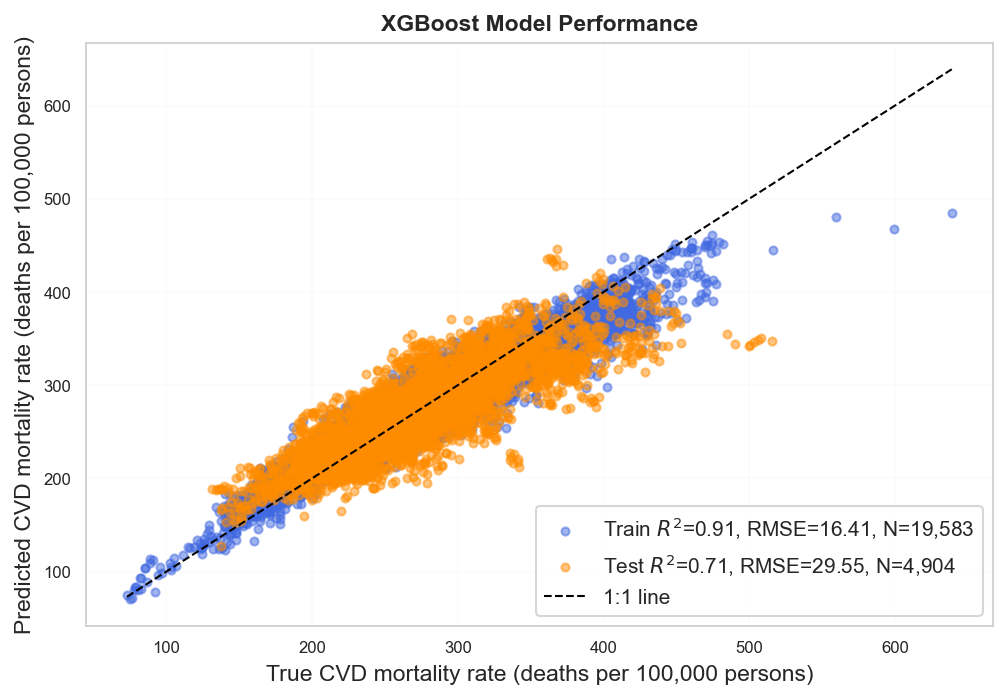

Saved scatter performance figure to: data_cvd/outputs/modeling/xgboost/revision/canonical_scatter_performance.png


In [21]:
scatter_path = OUTPUT_DIR / 'canonical_scatter_performance.png'
save_scatter_performance(y_train, train_pred, y_test, test_pred, scatter_path)
print(f'Saved scatter performance figure to: {project_relative_path(scatter_path)}')

## 6. Permutation-Based Feature Importance

Permutation importance estimates the decrease in predictive performance when each feature is randomly shuffled in the held-out test set. Larger decreases indicate stronger reliance of the fitted model on that predictor.

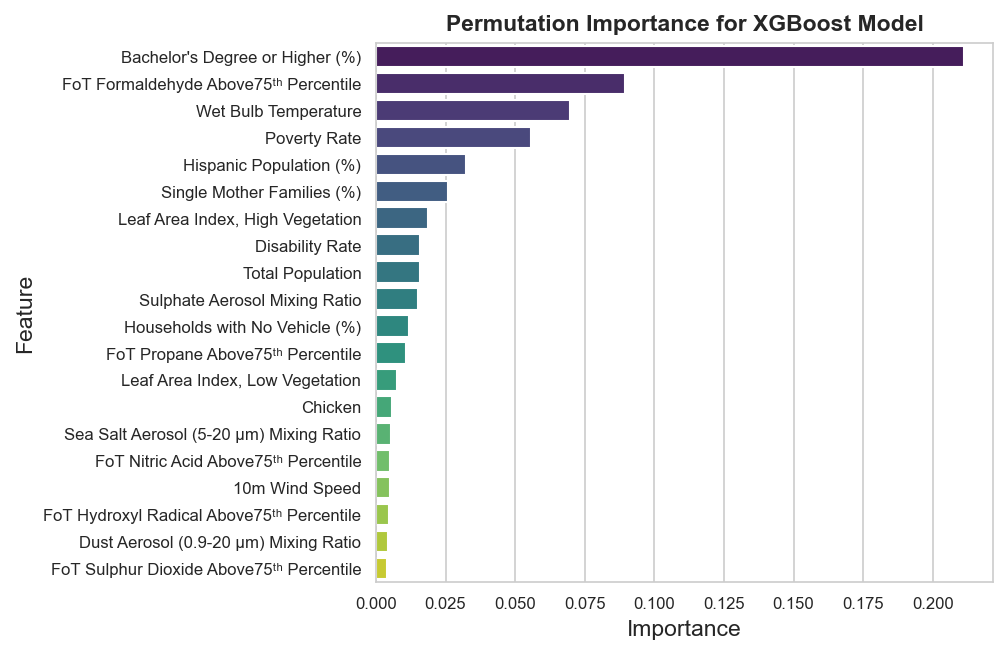

                              Feature                       Display Feature  Importance  Rank
      Bachelor's Degree or Higher (%)       Bachelor's Degree or Higher (%)    0.211090     1
FoT Formaldehyde Above75ᵗʰ Percentile FoT Formaldehyde Above75ᵗʰ Percentile    0.089544     2
                 Wet Bulb Temperature                  Wet Bulb Temperature    0.069619     3
                         Poverty Rate                          Poverty Rate    0.055769     4
              Hispanic Population (%)               Hispanic Population (%)    0.032368     5
           Single Mother Families (%)            Single Mother Families (%)    0.025832     6
     Leaf Area Index, High Vegetation      Leaf Area Index, High Vegetation    0.018841     7
                      Disability Rate                       Disability Rate    0.015964     8
                     Total Population                      Total Population    0.015724     9
        Sulphate Aerosol Mixing Ratio         Sulphate Aeros

In [22]:
permutation_csv_path = OUTPUT_DIR / 'canonical_permutation_importance.csv'
permutation_fig_path = OUTPUT_DIR / 'canonical_permutation_importance.png'

permutation_importance_df = save_permutation_importance(
    canonical_model,
    X_test,
    y_test,
    permutation_csv_path,
    permutation_fig_path,
)

print(permutation_importance_df.head(10).to_string(index=False))
print(f'\nSaved permutation importance CSV to: {project_relative_path(permutation_csv_path)}')
print(f'Saved permutation importance figure to: {project_relative_path(permutation_fig_path)}')

## 7. SHAP Feature Attribution

SHAP values quantify each feature's contribution to individual model predictions. The ranking table summarizes mean absolute SHAP values across held-out county-year observations, and the beeswarm plot shows both magnitude and direction of feature effects.

Creating SHAP explainer...


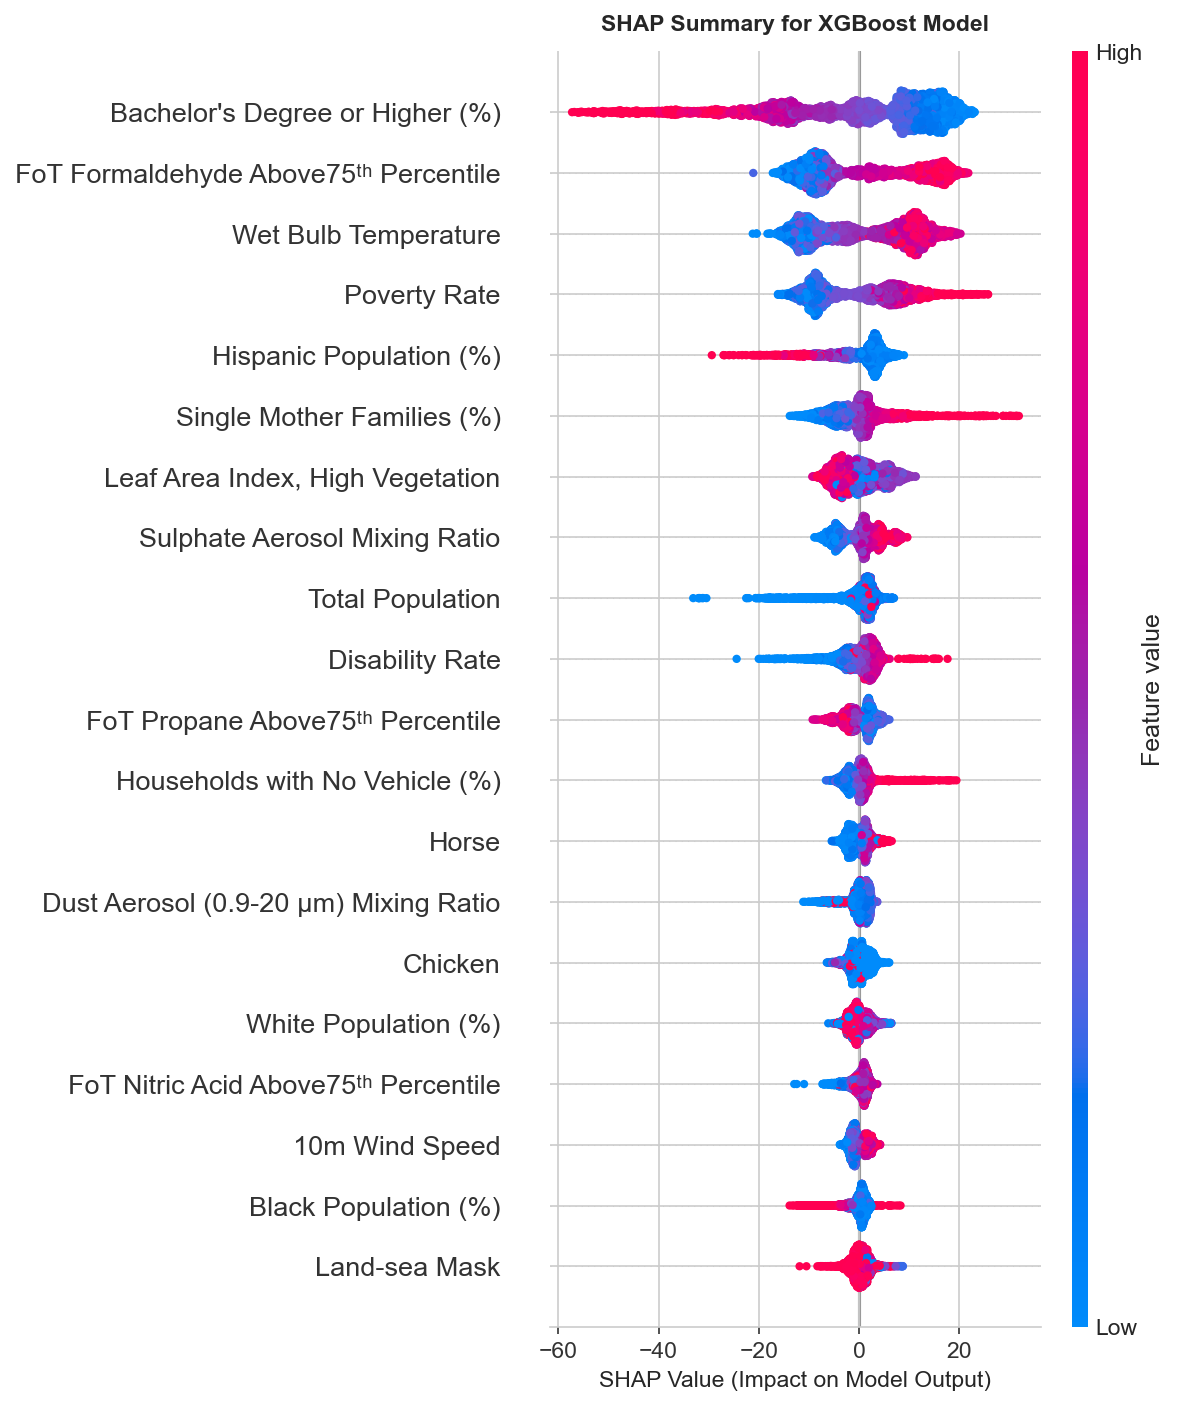

                              Feature                       Display Feature  Mean |SHAP|  Rank
      Bachelor's Degree or Higher (%)       Bachelor's Degree or Higher (%)    14.085009     1
FoT Formaldehyde Above75ᵗʰ Percentile FoT Formaldehyde Above75ᵗʰ Percentile    10.183089     2
                 Wet Bulb Temperature                  Wet Bulb Temperature     9.369663     3
                         Poverty Rate                          Poverty Rate     7.957727     4
              Hispanic Population (%)               Hispanic Population (%)     4.194235     5
           Single Mother Families (%)            Single Mother Families (%)     3.981846     6
     Leaf Area Index, High Vegetation      Leaf Area Index, High Vegetation     3.511621     7
        Sulphate Aerosol Mixing Ratio         Sulphate Aerosol Mixing Ratio     3.390967     8
                     Total Population                      Total Population     2.765847     9
                      Disability Rate             

In [23]:
shap_ranking_path = OUTPUT_DIR / 'canonical_shap_ranking.csv'
shap_values_path = OUTPUT_DIR / 'canonical_shap_values.npy'
shap_summary_path = OUTPUT_DIR / 'canonical_shap_summary.png'

shap_values, shap_ranking_df = compute_and_save_shap(
    canonical_model,
    X_test,
    shap_ranking_path,
    shap_values_path,
    shap_summary_path,
)

print(shap_ranking_df.head(10).to_string(index=False))

formaldehyde_rank = shap_ranking_df.loc[
    shap_ranking_df['Feature'] == FORMALDEHYDE_FEATURE,
    'Rank'
]
if not formaldehyde_rank.empty:
    print(f'\nFormaldehyde SHAP rank: {int(formaldehyde_rank.iloc[0])}')
else:
    print('\nFormaldehyde feature was not found in the SHAP ranking table.')

print(f'\nSaved SHAP values to: {project_relative_path(shap_values_path)}')
print(f'Saved SHAP ranking CSV to: {project_relative_path(shap_ranking_path)}')
print(f'Saved SHAP summary figure to: {project_relative_path(shap_summary_path)}')

## 8. SHAP Dependence Profiles for Leading Predictors

Dependence plots show how feature values relate to their SHAP contributions for the three highest-ranked predictors. These plots help identify nonlinear patterns, threshold behavior, and the direction of model-attributed effects.

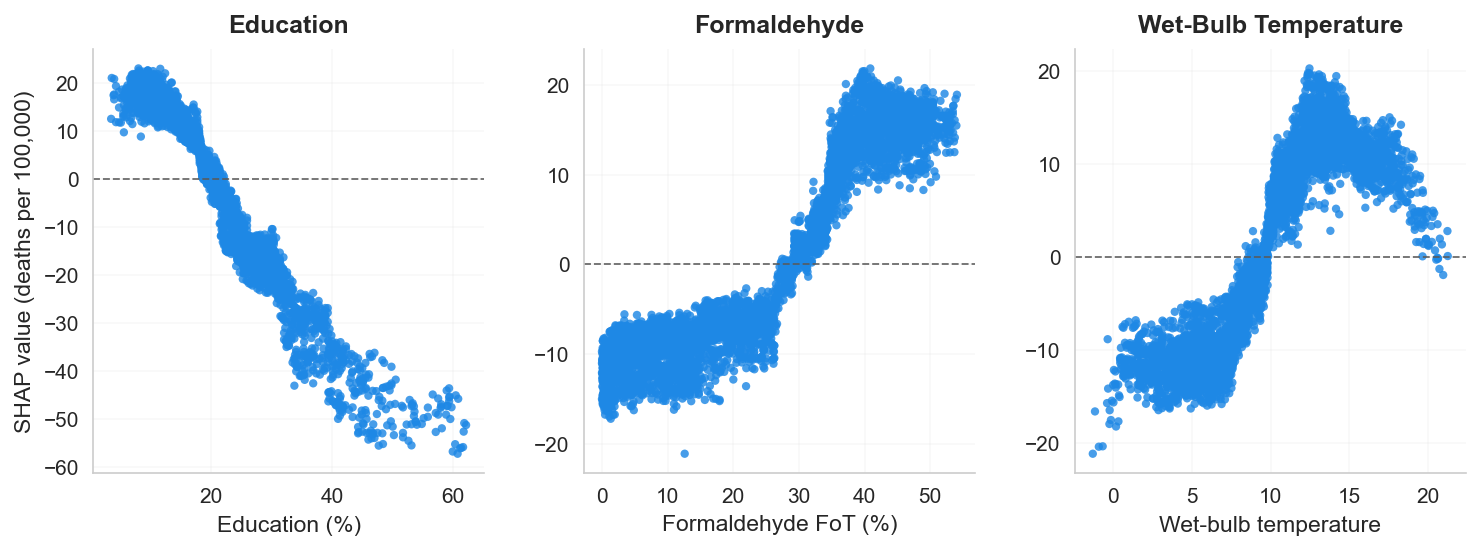

 Rank                               Feature                       Display Feature
    1       Bachelor's Degree or Higher (%)       Bachelor's degree or higher (%)
    2 FoT Formaldehyde Above75ᵗʰ Percentile FoT Formaldehyde Above75ᵗʰ Percentile
    3                  Wet Bulb Temperature                  Wet-Bulb Temperature

Saved SHAP dependence CSV to: data_cvd/outputs/modeling/xgboost/revision/canonical_shap_dependence_top3_features.csv
Saved SHAP dependence figure to: data_cvd/outputs/modeling/xgboost/revision/canonical_shap_dependence_top3.png


In [24]:
shap_dependence_csv_path = OUTPUT_DIR / 'canonical_shap_dependence_top3_features.csv'
shap_dependence_fig_path = OUTPUT_DIR / 'canonical_shap_dependence_top3.png'

shap_dependence_df = save_shap_dependence_top3(
    X_test,
    shap_values,
    shap_ranking_df,
    shap_dependence_csv_path,
    shap_dependence_fig_path,
)

print(shap_dependence_df.to_string(index=False))
print(f'\nSaved SHAP dependence CSV to: {project_relative_path(shap_dependence_csv_path)}')
print(f'Saved SHAP dependence figure to: {project_relative_path(shap_dependence_fig_path)}')

## 9. Residual Diagnostics

Residual diagnostics assess whether prediction errors show systematic structure with respect to fitted values and socioeconomic context. The distribution panel summarizes the spread and centering of held-out prediction errors.

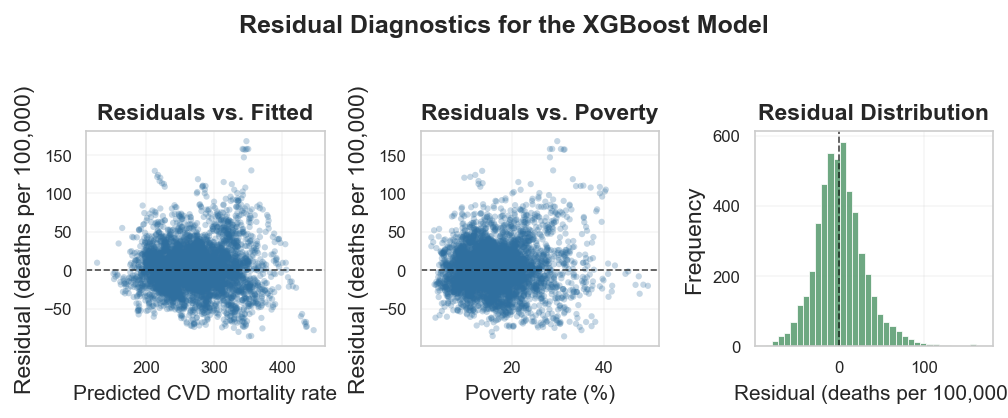

                        Metric       Value
                             N 4904.000000
                 Residual Mean    1.689358
               Residual Median   -0.105546
                   Residual SD   29.509057
                  Residual Min  -86.080127
                  Residual Max  167.894062
 Residual-Observed Correlation    0.548000
Residual-Predicted Correlation    0.008187
  Residual-Poverty Correlation    0.059472

Saved residual diagnostics summary to: data_cvd/outputs/modeling/xgboost/revision/canonical_residual_diagnostics_summary.csv
Saved residual diagnostics figure to: data_cvd/outputs/modeling/xgboost/revision/canonical_residual_diagnostics.png


In [25]:
residual_summary_path = OUTPUT_DIR / 'canonical_residual_diagnostics_summary.csv'
residual_fig_path = OUTPUT_DIR / 'canonical_residual_diagnostics.png'

residual_summary_df = save_residual_diagnostics(
    test_predictions,
    residual_summary_path,
    residual_fig_path,
)

print(residual_summary_df.to_string(index=False))
print(f'\nSaved residual diagnostics summary to: {project_relative_path(residual_summary_path)}')
print(f'Saved residual diagnostics figure to: {project_relative_path(residual_fig_path)}')

## 10. Artifact Verification

This final check verifies that all expected outputs from the preceding computations were written to disk. It is intended as a reproducibility guard before the outputs are used in manuscript figures, tables, or supplementary materials.

In [26]:
expected_outputs = [
    'canonical_split_metadata.csv',
    'canonical_model_metrics.csv',
    'canonical_train_predictions.csv',
    'canonical_test_predictions.csv',
    'canonical_shap_ranking.csv',
    'canonical_permutation_importance.csv',
    'canonical_shap_dependence_top3_features.csv',
    'canonical_residual_diagnostics_summary.csv',
    'canonical_scatter_performance.png',
    'canonical_shap_summary.png',
    'canonical_permutation_importance.png',
    'canonical_shap_dependence_top3.png',
    'canonical_residual_diagnostics.png',
    'canonical_shap_values.npy',
    'canonical_model.json',
]

missing_outputs = [name for name in expected_outputs if not (OUTPUT_DIR / name).exists()]

if missing_outputs:
    raise FileNotFoundError('Missing expected outputs: ' + ', '.join(missing_outputs))

print('Artifact checklist passed. All required files exist:')
for name in expected_outputs:
    print(f'- {project_relative_path(OUTPUT_DIR / name)}')

Artifact checklist passed. All required files exist:
- data_cvd/outputs/modeling/xgboost/revision/canonical_split_metadata.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_model_metrics.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_train_predictions.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_test_predictions.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_shap_ranking.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_permutation_importance.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_shap_dependence_top3_features.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_residual_diagnostics_summary.csv
- data_cvd/outputs/modeling/xgboost/revision/canonical_scatter_performance.png
- data_cvd/outputs/modeling/xgboost/revision/canonical_shap_summary.png
- data_cvd/outputs/modeling/xgboost/revision/canonical_permutation_importance.png
- data_cvd/outputs/modeling/xgboost/revision/canonical_shap_dependence_top3.png
- d